In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset
from torch.optim.lr_scheduler import StepLR, MultiStepLR, ExponentialLR, CosineAnnealingLR, ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_, clip_grad_value_
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

output_dir = '04_training_neural_networks_outputs'
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, "runs"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "saved_models"), exist_ok=True)


2026-04-08 15:14:11.482422: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775661251.708168      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775661251.775360      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775661252.315312      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775661252.315350      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775661252.315353      55 computation_placer.cc:177] computation placer alr

Using device: cuda


In [2]:
class MyCustomDataset(Dataset):
    """Ex of custom dataset"""
    def __init__(self, num_samples=1000, input_features=10, num_classes=2, transform=None):
        self.data = torch.randn(num_samples, input_features)
        self.targets = torch.randint(0, num_classes, (num_samples,))
        self.transform = transform
        print(f"CustomDataset: Created {num_samples} samples.")
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        sample = self.data[idx]
        target = self.targets[idx]
        if self.transform:
            sample = self.transform(sample)
        return sample, torch.tensor(target, dtype=torch.long)

print('Custom dataset ex')
custom_train_dataset = MyCustomDataset(num_samples=100, input_features=5, num_classes=3)
sample_data, sample_target = custom_train_dataset[0]
print(f"First sample data shape: {sample_data.shape}, target: {sample_target}")

custom_train_loader = DataLoader(custom_train_dataset, batch_size=32, shuffle=True)
print(f"Number of batches in custom_train_loader: {len(custom_train_loader)}")
for i, (batch_data, batch_targets) in enumerate(custom_train_loader):
    print(f"Batch {i+1} data shape: {batch_data.shape}, targets shape: {batch_targets.shape}")
    #if i == 0: 
        #break
        

Custom dataset ex
CustomDataset: Created 100 samples.
First sample data shape: torch.Size([5]), target: 1
Number of batches in custom_train_loader: 4
Batch 1 data shape: torch.Size([32, 5]), targets shape: torch.Size([32])
Batch 2 data shape: torch.Size([32, 5]), targets shape: torch.Size([32])
Batch 3 data shape: torch.Size([32, 5]), targets shape: torch.Size([32])
Batch 4 data shape: torch.Size([4, 5]), targets shape: torch.Size([4])


/tmp/ipykernel_55/1747142889.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return sample, torch.tensor(target, dtype=torch.long)


In [3]:
print("\ntorchvision MNIST Dataset and DataLoader Example")
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307), (0.3081,))
])

mnist_train_dataset = torchvision.datasets.MNIST(
    root='.data', train=True, download=True, transform=mnist_transform
)
mnist_train_loader = DataLoader(mnist_train_dataset, batch_size=64, shuffle=True)
print(f"Number of samples in MNIST traning set: {len(mnist_train_dataset)}")
print(f"Number of batches in MNIST train_loader: {len(mnist_train_loader)}")
mnist_batch_data, mnist_batch_targets = next(iter(mnist_train_loader))
print(f"MNIST first batch data shape: {mnist_batch_data.shape}, targets shape: {mnist_batch_targets.shape}")
print("'Dataset' manages data samples, 'DataLoader' provides batches for training.")


torchvision MNIST Dataset and DataLoader Example


100%|██████████| 9.91M/9.91M [00:00<00:00, 40.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.10MB/s]

Number of samples in MNIST traning set: 60000
Number of batches in MNIST train_loader: 938
MNIST first batch data shape: torch.Size([64, 1, 28, 28]), targets shape: torch.Size([64])
'Dataset' manages data samples, 'DataLoader' provides batches for training.


In [17]:
class SimpleNN(nn.Module):
    def __init__ (self, input_size=28*28, hidden_size=128, num_classes=10, use_dropout=False, use_bn=False):
        super(SimpleNN,self).__init__()
        self.use_dropout=use_dropout
        self.use_bn=use_bn
        self.fc1 = nn.Linear(input_size, hidden_size)

        if self.use_bn: 
            self.bn1 = nn.BatchNorm1d(hidden_size)
        self.relu = nn.ReLU()
        if self.use_dropout:
            self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        x = self.fc2(x)
        return x

In [6]:
dummy_inputs = torch.randn(64, 28*28).to(device)
dummy_targets = torch.randint(0, 10, (64,)).to(device)

model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print('Running one iteration of the training loop...')

model.train()

optimizer.zero_grad()

outputs = model(dummy_inputs)
print(f"Output shape: {outputs.shape}")

loss = criterion(outputs, dummy_targets)
print(f"Calculated loss: {loss.item():.4f}")

loss.backward()
print(f"Gradients computed (e.g., model.fc1.weight.grad is not None: {model.fc1.weight.grad is not None})")

optimizer.step()
print(f"Optimizer step taken (weights updated).")
print(f"This forms one iteration. A full epoch repeats this for all batches.")

Running one iteration of the training loop...
Output shape: torch.Size([64, 10])
Calculated loss: 2.3434
Gradients computed (e.g., model.fc1.weight.grad is not None: True)
Optimizer step taken (weights updated).
This forms one iteration. A full epoch repeats this for all batches.


In [7]:
def get_mnist_loaders(batch_size=64, validation_split=0.1):
    """Help func to get MNIST data loaders"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,),(0.3081,))
    ])
    full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    num_train = len(full_train_dataset)

    val_size = int(validation_split*num_train)
    train_size = num_train - val_size

    train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size = batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = get_mnist_loaders()
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 35.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.08MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.34MB/s]

Train batches: 844, Val batches: 94, Test batches: 157


In [8]:
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()

model.eval()
val_loss = 0.0
correct_predictions = 0
total_samples = 0

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        val_loss += loss.item()*inputs.size(0)
        _, predicted_classes = outputs.max(1)
        total_samples += targets.size(0)
        correct_predictions += predicted_classes.eq(targets).sum().item()

        if total_samples == inputs.size(0):
            print(f"Validation batch: Loss{loss.item():.4f}")
        if total_samples >= 256:
            break

epoch_loss = val_loss / total_samples
epoch_accuracy = correct_predictions / total_samples
print(f"Validation Results: Avarage Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy*100:.2f}%")
print("'model.eval()' and 'torch.no_grad()' are crucial for correct validation.")

Validation batch: Loss2.2813
Validation Results: Avarage Loss: 2.2857, Accuracy: 11.72%
'model.eval()' and 'torch.no_grad()' are crucial for correct validation.


In [9]:
model_to_save = SimpleNN().to(device)
optimizer = optim.Adam(model_to_save.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

dummy_input = torch.randn(10, 28*28).to(device)
dummy_target = torch.randint(0, 10, (10,)).to(device)
for _ in range(2):
    optimizer.zero_grad()
    loss = criterion(model_to_save(dummy_input), dummy_target)
    loss.backward()
    optimizer.step()

model_path = os.path.join(output_dir, "saved_models", "simple_nn_statedict.pth")
checkpoint_path = os.path.join(output_dir, "saved_models", "checkpoint.pth")

print('Saving and loading model state dictionary')
torch.save(model_to_save.state_dict(), model_path)
print(f"Model state_dict saved to: {model_path}")

model_loaded_state_dict = SimpleNN().to(device)
model_loaded_state_dict.load_state_dict(torch.load(model_path))
model_loaded_state_dict.eval()
print("Model loaded from state_dict successfully.")

Saving and loading model state dictionary
Model state_dict saved to: 04_training_neural_networks_outputs/saved_models/simple_nn_statedict.pth
Model loaded from state_dict successfully.


In [10]:
print('\nSaving and Loading Checkpoints')
epoch = 5
current_loss = 0.123

checkpoint = {
    'epoch': epoch + 1, 
    'model_state_dict': model_to_save.state_dict(), 
    'optimizer_state_dict': optimizer.state_dict(), 
    'loss': current_loss,
}
torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")

model_for_resume = SimpleNN().to(device)
optimizer_for_resume = optim.Adam(model_for_resume.parameters(), lr=0.001)

loaded_checkpoint = torch.load(checkpoint_path)
model_for_resume.load_state_dict(loaded_checkpoint['model_state_dict'])
start_epoch = loaded_checkpoint['epoch']
previous_loss = loaded_checkpoint['loss']
model_for_resume.train()
print(f"Checkpoint loaded. Resuming from epoch {start_epoch}, previous loss: {previous_loss:.4f}")
print("Always save 'state_dict' for portability and flexibility.")



Saving and Loading Checkpoints
Checkpoint saved to: 04_training_neural_networks_outputs/saved_models/checkpoint.pth
Checkpoint loaded. Resuming from epoch 6, previous loss: 0.1230
Always save 'state_dict' for portability and flexibility.


/tmp/ipykernel_55/1187466006.py:36: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  current_scheduler.step()


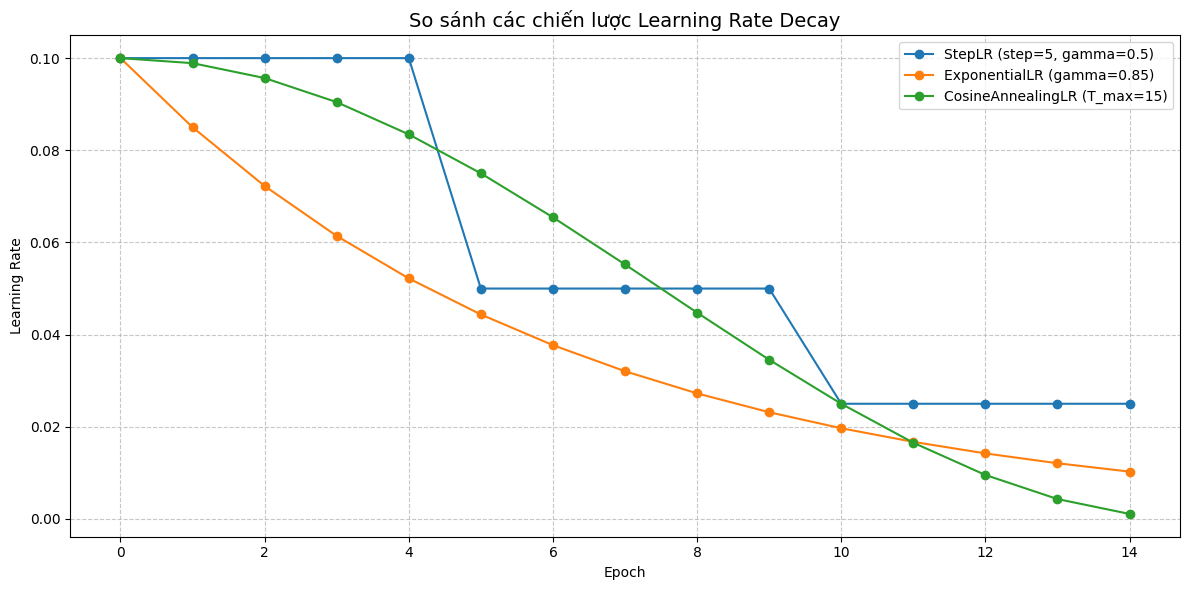

Mỗi scheduler tạo ra một kiểu suy giảm Learning Rate khác nhau để giúp model hội tụ tốt hơn.


In [12]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR
import matplotlib.pyplot as plt

# 1. Sửa lỗi tên biến (thêm dấu gạch dưới)
num_epochs_lr_demo = 15 

# Giả định bạn đã định nghĩa SimpleNN và device ở trên
model = SimpleNN(hidden_size=32).to(device)

# Định nghĩa các cấu hình để test
schedulers_to_test = [
    ("StepLR (step=5, gamma=0.5)", "StepLR"),
    ("ExponentialLR (gamma=0.85)", "ExponentialLR"),
    ("CosineAnnealingLR (T_max=15)", "CosineAnnealingLR")
]

plt.figure(figsize=(12, 6))

for label, type_name in schedulers_to_test:
    # Reset optimizer cho mỗi loại scheduler để công bằng (đều bắt đầu từ lr=0.1)
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    
    # Khởi tạo scheduler tương ứng
    if type_name == "StepLR":
        current_scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    elif type_name == "ExponentialLR":
        current_scheduler = ExponentialLR(optimizer, gamma=0.85)
    elif type_name == "CosineAnnealingLR":
        current_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_lr_demo)
    
    lr_history = []
    for epoch in range(num_epochs_lr_demo):
        lr_history.append(optimizer.param_groups[0]['lr'])
        current_scheduler.step()
    
    plt.plot(lr_history, label=label, marker='o') 

plt.title("So sánh các chiến lược Learning Rate Decay", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Mỗi scheduler tạo ra một kiểu suy giảm Learning Rate khác nhau để giúp model hội tụ tốt hơn.")

In [13]:
# --- L2 Regularization (Weight Decay) ---
print("--- L2 Regularization (Weight Decay) ---")
model_wd = SimpleNN().to(device)

optimizer_wd = optim.Adam(model_wd.parameters(), lr=0.001, weight_decay=1e-4)
print(f"Optimizer with weight_decay (L2 penalty): weight_decay={optimizer_wd.param_groups[0]['weight_decay']}")

print("\n--- Dropout ---")
model_dropout = SimpleNN(use_dropout=True).to(device)
print("Model with Dropout layer:")
print(model_dropout)

dummy_input_reg = torch.randn(5, 28*28).to(device)

model_dropout.train()
output_train = model_dropout(dummy_input_reg)
print(f"Output with dropout (train mode): {output_train[0,:5]}")

model_dropout.eval()
with torch.no_grad():
    output_eval = model_dropout(dummy_input_reg)
print(f"Output with dropout (eval mode): {output_eval[0,:5]}")

print("\nDuring training, dropout randomly zeros elements. During evaluation, all neurons are used and outputs are scaled.")

--- L2 Regularization (Weight Decay) ---
Optimizer with weight_decay (L2 penalty): weight_decay=0.0001

--- Dropout ---
Model with Dropout layer:
SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Output with dropout (train mode): tensor([-0.3690, -0.4757, -0.3212, -0.3737, -0.0649], device='cuda:0',
       grad_fn=<SliceBackward0>)
Output with dropout (eval mode): tensor([-0.4226, -0.2570, -0.4548, -0.2672,  0.0608], device='cuda:0')

During training, dropout randomly zeros elements. During evaluation, all neurons are used and outputs are scaled.


In [15]:
model_gc = SimpleNN().to(device)
optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.01)
criterion_gc = nn.MSELoss()
dummy_input_gc = torch.randn(5, 28*28).to(device)
dummy_target_gc = torch.randn(5, 10).to(device)
optimizer_gc.zero_grad()
outputs_gc = model_gc(dummy_input_gc)
loss_gc = criterion_gc(outputs_gc, dummy_target_gc)
loss_gc.backward()
# Print norm of gradients before clipping
original_grad_norm = model_gc.fc1.weight.grad.norm().item()
print(f"Original grad norm for fc1.weight: {original_grad_norm:.4f}")
# Clip gradient norm
max_norm = 1.0
total_norm_clipped = clip_grad_norm_(model_gc.parameters(), max_norm=max_norm)
print(f"Total norm of gradients after clipping by norm to {max_norm}: {total_norm_clipped:.4f}")
clipped_grad_norm = model_gc.fc1.weight.grad.norm().item()
print(f"Clipped grad norm for fc1.weight: {clipped_grad_norm:.4f}")
# Demonstrate gradient value clipping
optimizer_gc.zero_grad()
outputs_gc = model_gc(dummy_input_gc)
loss_gc = criterion_gc(outputs_gc, dummy_target_gc)
loss_gc.backward()
clip_val = 0.1
clip_grad_value_(model_gc.parameters(), clip_value=clip_val)
print(f"\nAfter clipping values to +/- {clip_val}:")
print(f" Min grad value: {model_gc.fc1.weight.grad.min().item():.4f}")
print(f" Max grad value: {model_gc.fc1.weight.grad.max().item():.4f}")
print("Gradient clipping is applied after .backward() and before .step().")

Original grad norm for fc1.weight: 3.3670
Total norm of gradients after clipping by norm to 1.0: 3.6801
Clipped grad norm for fc1.weight: 0.9149

After clipping values to +/- 0.1:
 Min grad value: -0.0865
 Max grad value: 0.0799
Gradient clipping is applied after .backward() and before .step().


In [18]:
model_with_bn = SimpleNN(use_bn=True).to(device)
print("Model with Batch Normalization layer:")
print(model_with_bn)
dummy_input_bn = torch.randn(5, 28*28).to(device)

# Behavior in train() mode
model_with_bn.train()
output_bn_train = model_with_bn(dummy_input_bn)
print(f"\nOutput with BatchNorm (train mode) shape: {output_bn_train.shape}")
print(f"Running mean of bn1 after one forward pass (train): {model_with_bn.bn1.running_mean[0].item():.4f}")

# Behavior in eval() mode
model_with_bn.eval()
output_bn_eval = model_with_bn(dummy_input_bn)
print(f"Output with BatchNorm (eval mode) shape: {output_bn_eval.shape}")
print("`model.train()` and `model.eval()` are crucial for BatchNorm to work correctly.")
print("In train mode, BN uses batch statistics and updates running mean/var.")
print("In eval mode, BN uses computed running mean/var and does not update them.")

Model with Batch Normalization layer:
SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Output with BatchNorm (train mode) shape: torch.Size([5, 10])
Running mean of bn1 after one forward pass (train): 0.0143
Output with BatchNorm (eval mode) shape: torch.Size([5, 10])
`model.train()` and `model.eval()` are crucial for BatchNorm to work correctly.
In train mode, BN uses batch statistics and updates running mean/var.
In eval mode, BN uses computed running mean/var and does not update them.


In [19]:
# Configuration
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 2 # Low for demo, typically 10-100+
HIDDEN_SIZE = 256
WEIGHT_DECAY = 1e-5
CLIP_GRAD_NORM = 1.0

# Data Loading
train_loader, val_loader, test_loader = get_mnist_loaders(batch_size=BATCH_SIZE)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# Model Definition with regularization
model = SimpleNN(28*28, HIDDEN_SIZE, 10, use_dropout=True, use_bn=True).to(device)

# Initialize weights
for m in model.modules():
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

print("Model and training setup complete.")

Train batches: 422, Val batches: 47
Model and training setup complete.



Epoch 1/2
 Batch 100/422 | Loss: 0.4291 | Acc: 85.94%
 Batch 200/422 | Loss: 0.1373 | Acc: 95.31%
 Batch 300/422 | Loss: 0.2400 | Acc: 91.41%
 Batch 400/422 | Loss: 0.2558 | Acc: 90.62%
Train Loss: 0.3668, Train Acc: 88.73%
Val Loss: 0.1668, Val Acc: 95.32%
Learning Rate: 0.001000

Epoch 2/2
 Batch 100/422 | Loss: 0.1300 | Acc: 96.88%
 Batch 200/422 | Loss: 0.1870 | Acc: 95.31%
 Batch 300/422 | Loss: 0.1610 | Acc: 93.75%
 Batch 400/422 | Loss: 0.2139 | Acc: 92.97%
Train Loss: 0.1994, Train Acc: 94.04%
Val Loss: 0.1275, Val Acc: 96.38%
Learning Rate: 0.001000

Training completed!


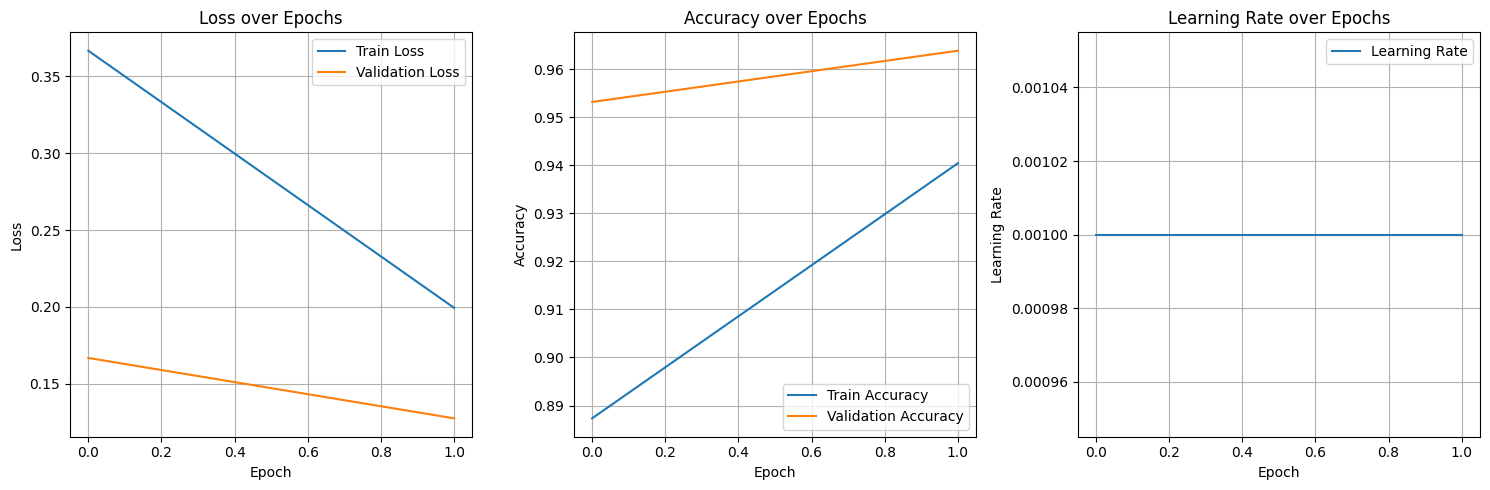

Training history visualization complete.


In [20]:
# Training Loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Training Phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        
        # Gradient Clipping
        if CLIP_GRAD_NORM > 0:
            clip_grad_norm_(model.parameters(), max_norm=CLIP_GRAD_NORM)
            
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        train_total += targets.size(0)
        train_correct += predicted.eq(targets).sum().item()
        
        if (batch_idx + 1) % 100 == 0:
            batch_acc = predicted.eq(targets).sum().item() / targets.size(0)
            print(f' Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f} | Acc: {batch_acc*100:.2f}%')

    avg_train_loss = train_loss / train_total
    avg_train_acc = train_correct / train_total
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()
            
    avg_val_loss = val_loss / val_total
    avg_val_acc = val_correct / val_total
    
    # Update scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val_loss)
    
    # Store history
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(avg_train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(avg_val_acc)
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc*100:.2f}%")
    print(f"Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc*100:.2f}%")
    print(f"Learning Rate: {current_lr:.6f}")

print("\nTraining completed!")

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history['lr'], label='Learning Rate')
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print("Training history visualization complete.")